# SYTEME DE PREDICTION DU FUTURE METIER D'UN ELEVE EN FONCTION DE SES NOTES

# 1- EXPLORATION DES DONNEES

In [3]:
import numpy as np

1.1- Importation des bibiotheques

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, learning_curve 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample


1.2- Affiche du dataset

In [5]:
df=pd.read_csv("student-scores.csv")
df

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,Alan,Reynolds,alan.reynolds.1996@gslingacademy.com,male,False,2,False,30,Construction Engineer,83,77,84,73,75,84,82
1996,1997,Thomas,Gilbert,thomas.gilbert.1997@gslingacademy.com,male,False,2,False,20,Software Engineer,89,65,73,80,87,67,73
1997,1998,Madison,Cross,madison.cross.1998@gslingacademy.com,female,False,5,False,14,Software Engineer,97,85,63,93,68,94,78
1998,1999,Brittany,Compton,brittany.compton.1999@gslingacademy.com,female,True,10,True,5,Business Owner,51,96,72,89,95,88,75


1.3- Affiche les colonnes

In [6]:
df.columns

Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score'],
      dtype='object')

1.

In [7]:
df.shape

(2000, 17)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

In [9]:
df.describe()

,id,absence_days,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,3.665500,17.755500,83.452000,80.332000,81.336500,79.995000,79.58150,81.277500,80.888000
std,577.494589,2.629271,12.129604,13.224906,12.736046,12.539453,12.777895,13.72219,12.027087,11.637705
min,1.000000,0.000000,0.000000,40.000000,50.000000,50.000000,50.000000,30.00000,50.000000,60.000000
25%,500.750000,2.000000,5.000000,77.000000,69.750000,71.000000,69.000000,69.00000,72.000000,71.000000
50%,1000.500000,3.000000,18.000000,87.000000,82.000000,83.000000,81.000000,81.00000,83.000000,81.000000
75%,1500.250000,5.000000,28.000000,93.000000,91.000000,92.000000,91.000000,91.00000,91.000000,91.000000
max,2000.000000,10.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,99.000000,100.000000


In [10]:
df.isnull().sum()

id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

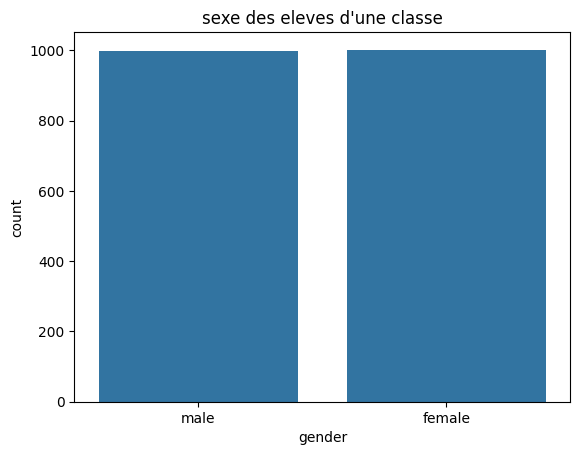

In [11]:
sns.countplot(x="gender", data=df)
plt.title("sexe des eleves d'une classe")
plt.show()

<Axes: xlabel='extracurricular_activities'>

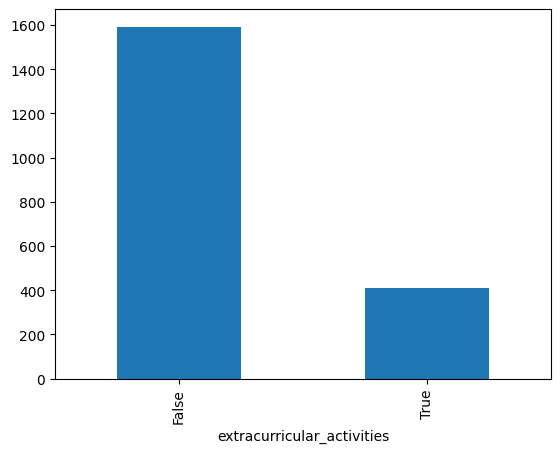

In [12]:
df['extracurricular_activities'].value_counts().plot(kind='bar')

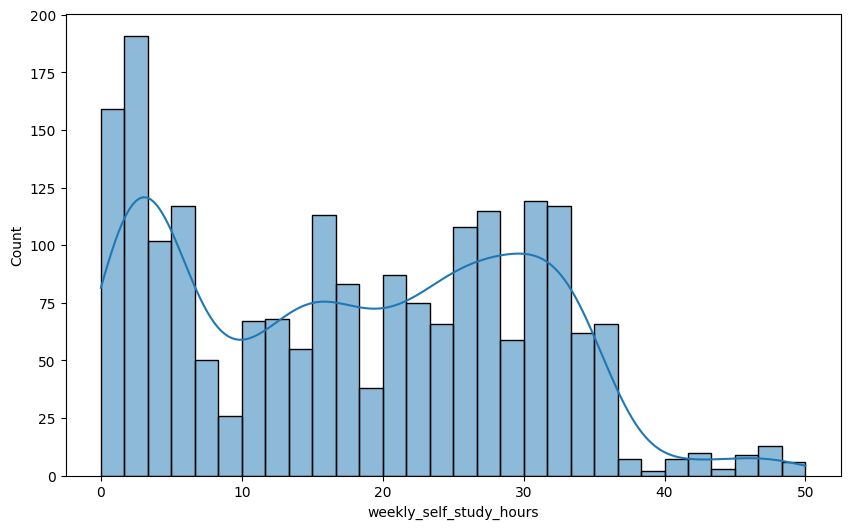

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df['weekly_self_study_hours'], bins=30, kde=True)
plt.show()

career_aspiration
Software Engineer        315
Business Owner           309
Unknown                  223
Banker                   169
Lawyer                   138
Accountant               126
Doctor                   119
Real Estate Developer     83
Stock Investor            73
Construction Engineer     68
Artist                    67
Game Developer            63
Government Officer        61
Teacher                   59
Designer                  56
Scientist                 39
Writer                    32
Name: count, dtype: int64


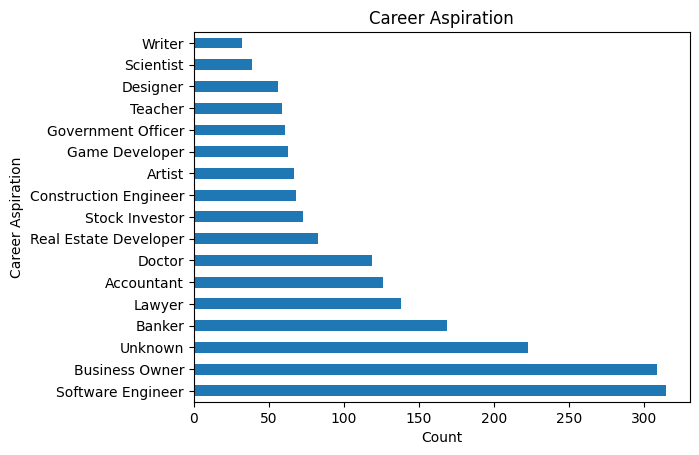

In [14]:
ax = df['career_aspiration'].value_counts().plot(kind='barh', title='Career Aspiration')
ax.set_ylabel('Career Aspiration')
ax.set_xlabel('Count')
print(df['career_aspiration'].value_counts())

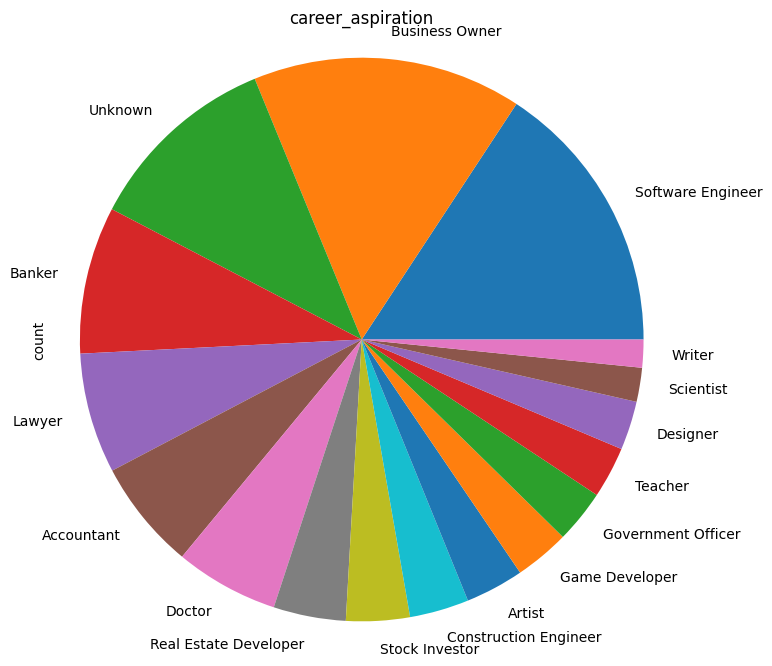

In [15]:
plt.figure(figsize=(8, 8))
df['career_aspiration'].value_counts().plot(kind='pie')
plt.title('career_aspiration')
plt.axis('equal')
plt.show()

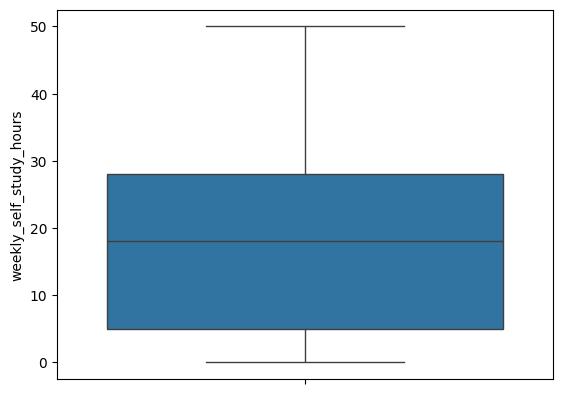

In [16]:
sns.boxplot(data=df,y="weekly_self_study_hours")
plt.show()

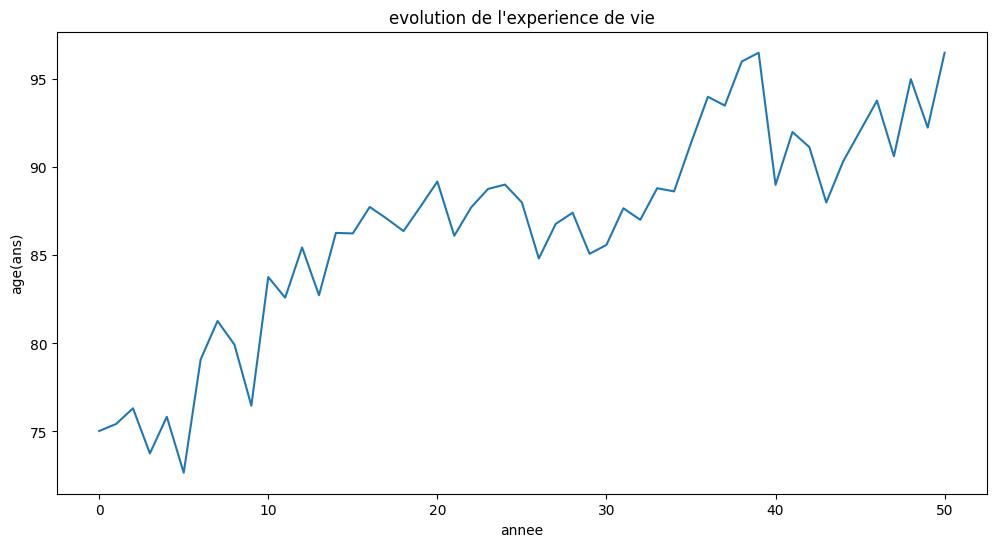

In [17]:
mean_life_by_year= df.groupby("weekly_self_study_hours")["math_score"].mean()
plt.figure(figsize=(12,6))
sns.lineplot(x=mean_life_by_year.index, y=mean_life_by_year.values)
plt.title("evolution de l'experience de vie")
plt.xlabel("annee")
plt.ylabel("age(ans)")
plt.show()

# 2- TRAITEMENT DES DONNEES

In [18]:
df['math'] = (df['math_score'] * 20 ) /100
df['history'] = (df['history_score'] * 20) /100
df['physics'] = (df['physics_score'] * 20) /100
df['chemistry'] = (df['chemistry_score'] * 20) /100
df['biology'] = (df['biology_score'] * 20) /100
df['english'] = (df['english_score'] * 20) /100
df['geography'] = (df['geography_score'] * 20) /100

In [19]:
df = df.drop(['id','first_name','last_name','email','math_score','history_score','physics_score','chemistry_score','biology_score','english_score','geography_score'], axis=1)
df

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math,history,physics,chemistry,biology,english,geography
0,male,False,3,False,27,Lawyer,14.6,16.2,18.6,19.4,12.6,16.0,17.4
1,female,False,2,False,47,Doctor,18.0,17.2,19.2,20.0,18.0,17.6,18.0
2,female,False,9,True,13,Government Officer,16.2,19.4,19.0,19.2,13.0,15.4,18.8
3,female,False,5,False,3,Artist,14.2,14.8,17.6,16.0,17.8,12.6,17.2
4,male,False,5,False,10,Unknown,16.8,15.4,13.0,13.0,16.0,14.8,15.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,male,False,2,False,30,Construction Engineer,16.6,15.4,16.8,14.6,15.0,16.8,16.4
1996,male,False,2,False,20,Software Engineer,17.8,13.0,14.6,16.0,17.4,13.4,14.6
1997,female,False,5,False,14,Software Engineer,19.4,17.0,12.6,18.6,13.6,18.8,15.6
1998,female,True,10,True,5,Business Owner,10.2,19.2,14.4,17.8,19.0,17.6,15.0


In [20]:
df.shape

(2000, 13)

In [21]:
label_cols = ['gender','part_time_job','extracurricular_activities','career_aspiration']
encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col]= le # pour décoder plus tard si besoin

In [22]:
df["moyenne"] = df[
    ["math", "physics", "chemistry", "biology", "english", "geography","history"]
].mean(axis=1)


In [23]:
df.drop(
    columns=["math", "physics", "chemistry", "biology", "english", "geography","history"],
    inplace=True
)


In [24]:
df

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,moyenne
0,1,0,3,0,27,9,16.400000
1,0,0,2,0,47,6,18.285714
2,0,0,9,1,13,8,17.285714
3,0,0,5,0,3,1,15.742857
4,1,0,5,0,10,15,14.885714
...,...,...,...,...,...,...,...
1995,1,0,2,0,30,4,15.942857
1996,1,0,2,0,20,12,15.257143
1997,0,0,5,0,14,12,16.514286
1998,0,1,10,1,5,3,16.171429


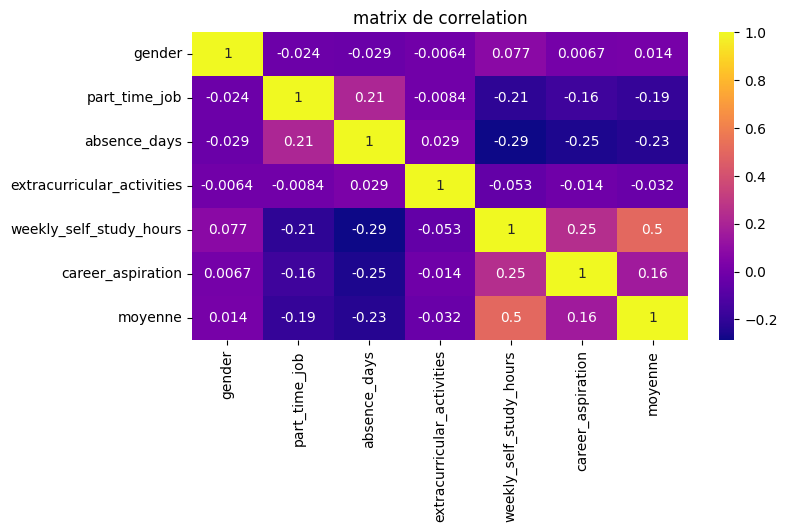

In [25]:
matrix = df.corr()
plt.figure(figsize=(8,4))
sns.heatmap(matrix, annot = True, cmap = "plasma")
plt.title("matrix de correlation")
plt.show()

In [26]:
df.shape

(2000, 7)

# 3- ENTRAINEMENT ET EVALUATION DU MODELE

In [27]:
X=df.drop('career_aspiration' , axis=1)
y=df['career_aspiration']

In [28]:
# Étape 1 : Combiner X et y dans un DataFrame pour équilibrage
df_bal = pd.concat([X, y], axis=1)

In [29]:
# Étape 2 : Trouver la classe majoritaire
max_count = df_bal['career_aspiration'].value_counts().max()

In [30]:

# Étape 3 : Sur-échantillonner chaque classe
df_resampled = pd.DataFrame()
for label in df_bal['career_aspiration'].unique():
    df_label = df_bal[df_bal['career_aspiration'] == label]
    df_label_resampled = resample(df_label,
                                   replace=True,
                                   n_samples=max_count,
                                   random_state=42)
    df_resampled = pd.concat([df_resampled, df_label_resampled])

In [31]:
# Étape 4 : Réobtenir X et y équilibrés
X_balanced = df_resampled[X.columns]
y_balanced = df_resampled['career_aspiration']

In [32]:
# Étape 5 : Split train/test
X_train, X_test, y_train, y_test = train_test_split( X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=42)

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
modell = LogisticRegression(max_iter=1000)
modell.fit(X_train, y_train)
y_pred = modell.predict(X_test)

print("=== Logistic Regression (non optimisé) ===")
print(classification_report(y_test, y_pred))

=== Logistic Regression (non optimisé) ===
              precision    recall  f1-score   support

           0       0.23      0.33      0.27        63
           1       0.40      0.54      0.46        63
           2       0.21      0.11      0.14        63
           3       0.68      0.79      0.73        63
           4       0.23      0.59      0.33        63
           5       0.03      0.02      0.02        63
           6       0.51      0.63      0.56        63
           7       0.40      0.43      0.42        63
           8       0.36      0.24      0.29        63
           9       0.20      0.21      0.20        63
          10       0.20      0.16      0.18        63
          11       0.38      0.37      0.37        63
          12       0.00      0.00      0.00        63
          13       0.06      0.03      0.04        63
          14       0.31      0.71      0.43        63
          15       0.00      0.00      0.00        63
          16       0.00      0.00     

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
from sklearn.ensemble import RandomForestClassifier

modelr = RandomForestClassifier()
modelr.fit(X_train, y_train)
y_pred = modelr.predict(X_test)

print("=== Random Forest (non optimisé) ===")
print(classification_report(y_test, y_pred))

=== Random Forest (non optimisé) ===
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        63
           1       0.90      0.98      0.94        63
           2       0.81      0.86      0.83        63
           3       1.00      0.92      0.96        63
           4       0.90      0.97      0.93        63
           5       0.94      1.00      0.97        63
           6       0.91      0.92      0.91        63
           7       0.98      1.00      0.99        63
           8       0.98      1.00      0.99        63
           9       0.88      0.84      0.86        63
          10       0.95      0.97      0.96        63
          11       0.93      1.00      0.96        63
          12       0.87      0.63      0.73        63
          13       0.90      1.00      0.95        63
          14       0.89      0.98      0.93        63
          15       0.90      0.75      0.82        63
          16       1.00      1.00      1.00 

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

modelg = GradientBoostingClassifier()
modelg.fit(X_train, y_train)
y_pred = modelg.predict(X_test)

print("=== Gradient Boosting (non optimisé) ===")
print(classification_report(y_test, y_pred))

=== Gradient Boosting (non optimisé) ===
              precision    recall  f1-score   support

           0       0.57      0.52      0.55        63
           1       0.69      0.76      0.72        63
           2       0.57      0.41      0.48        63
           3       0.93      0.90      0.92        63
           4       0.66      0.75      0.70        63
           5       0.72      0.67      0.69        63
           6       0.86      0.79      0.83        63
           7       0.73      0.89      0.80        63
           8       0.75      0.75      0.75        63
           9       0.57      0.59      0.58        63
          10       0.80      0.81      0.80        63
          11       0.66      1.00      0.80        63
          12       0.44      0.29      0.35        63
          13       0.64      0.51      0.57        63
          14       0.66      0.95      0.78        63
          15       0.69      0.38      0.49        63
          16       0.82      0.89      0

In [37]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

print("K-Nearest Neighbors")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, zero_division=0))

K-Nearest Neighbors
Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.47      0.59      0.52        63
           1       0.73      0.86      0.79        63
           2       0.46      0.40      0.43        63
           3       0.83      0.79      0.81        63
           4       0.77      0.76      0.77        63
           5       0.79      0.89      0.84        63
           6       0.79      0.73      0.76        63
           7       0.87      0.87      0.87        63
           8       0.78      0.92      0.85        63
           9       0.55      0.57      0.56        63
          10       0.75      0.71      0.73        63
          11       0.78      0.98      0.87        63
          12       0.60      0.24      0.34        63
          13       0.63      0.60      0.62        63
          14       0.73      0.94      0.82        63
          15       0.58      0.29      0.38        63
          16       0.85      1.0

In [38]:
 # Standardisation (utile pour LogisticRegression et SVC)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [39]:
svc_model = SVC(kernel='rbf', C=1.0)
svc_model.fit(X_train_scaled, y_train)

y_pred_svc = svc_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_svc))

Accuracy: 0.39869281045751637


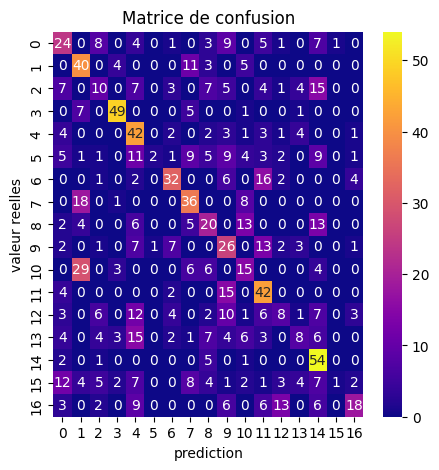

In [40]:
# Décodage des labels pour la matrice
y_test_labels = encoders['career_aspiration'].inverse_transform(y_test)
y_pred_labels = encoders['career_aspiration'].inverse_transform(y_pred)
cm = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot = True, fmt='d', cmap='plasma')
plt.title('Matrice de confusion')
plt.xlabel('prediction')
plt.ylabel('valeur reelles')
plt.show()

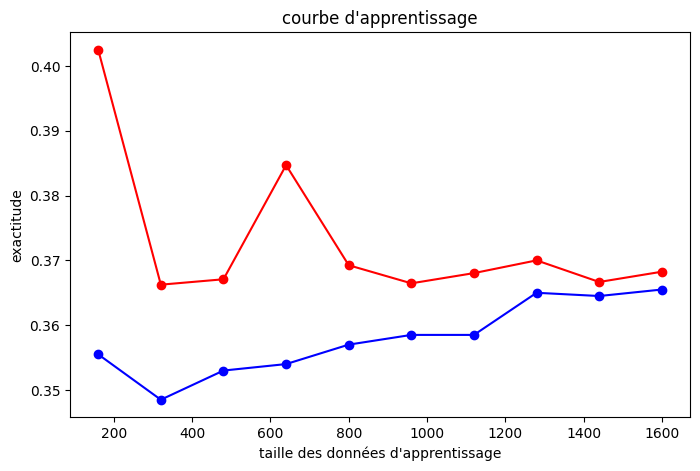

In [41]:
train_sizes, train_scores, test_scores = learning_curve(svc_model, X, y, cv = 5, scoring = "accuracy", train_sizes= np.linspace( 0.1,1.0, 10), random_state = 42)
plt.figure(figsize = (8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis = 1), "o-", color = "r", label = "score d'entrainement")
plt.plot(train_sizes, np.mean(test_scores, axis = 1),"o-", color = "b", label = "score_validation")
plt.title("courbe d'apprentissage")
plt.xlabel("taille des données d'apprentissage")
plt.ylabel("exactitude")
plt.show()

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# 5. Calcul des métriques
accuracy = accuracy_score(y_test, y_pred_svc)
precision = precision_score(y_test, y_pred_svc, average='macro')  # ou 'micro', 'weighted'
recall = recall_score(y_test, y_pred_svc, average='macro')
f1 = f1_score(y_test, y_pred_svc, average='macro')

# 6. Affichage
print(" Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print(" Recall    :", round(recall, 4))
print("F1-score  :", round(f1, 4))

 Accuracy  : 0.3987
Precision : 0.4215
 Recall    : 0.3987
F1-score  : 0.3598


# 5- SAUVEGARDE DU MODELE

In [43]:
# Sauvegarde dans un fichier .pkl
joblib.dump(svc_model, 'modele_metier.pkl')

['modele_metier.pkl']

In [44]:
joblib.dump(X.columns.tolist(), 'colonnes_modele.pkl')


['colonnes_modele.pkl']

In [45]:
from sklearn.preprocessing import LabelEncoder
joblib.dump(encoders, 'label_encoder.pkl')

['label_encoder.pkl']

In [46]:

joblib.dump(scaler, "scaler.pkl")



print("✅ Tous les objets pour Streamlit ont été enregistrés !")

✅ Tous les objets pour Streamlit ont été enregistrés !


import streamlit as st
import pandas as pd
import joblib
from PIL import Image
import os

# --------- PAGE CONFIG ---------
st.set_page_config(page_title="Orientation Carrière", layout="centered")

# --------- CSS GLOBAL (Fond noir + style université) ---------
st.markdown("""
<style>

/* 🌙 Thème général sombre */
body, .stApp {
    background-color: black !important;
    color: white !important;
}

/* Titres et textes */
h1, h2, h3, h4, h5, h6, label, p {
    color: white !important;
}

/* Boutons */
.stButton>button {
    background-color: #444444;
    color: white !important;
    font-weight: bold;
    border-radius: 8px;
    padding: 8px 16px;
}

/* Expander */
.stExpanderHeader {
    color: white !important;
}

/* Universités */
.univ-name { font-weight: bold; font-size: 16px; color: white; }
.univ-meta { font-size: 13px; color: #d0d0d0; }
.univ-desc { font-size: 13px; color: #bdbdbd; margin-bottom: 12px; }

/* ============================= */
/* ✅ SELECTBOX (LISTE DÉROULANTE) */
/* ============================= */

/* Boîte du selectbox */
div[data-baseweb="select"] > div {
    background-color: #1e1e1e !important;  /* fond sombre */
    color: white !important;               /* texte blanc */
    border-radius: 8px;
    border: 2px solid #00bcd4;
}

/* Texte sélectionné */
div[data-baseweb="select"] span {
    color: white !important;
}

/* Menu déroulant (liste) */
ul[role="listbox"] {
    background-color: #1e1e1e !important; /* fond noir */
    color: white !important;
    font-size: 15px;
}

/* Option au survol */
ul[role="listbox"] li:hover {
    background-color: #00bcd4 !important;
    color: black !important;
}

/* Champ input interne */
div[data-baseweb="select"] input {
    color: white !important;
}

</style>
""", unsafe_allow_html=True)



# --------- IMAGE D'ACCUEIL (optionnel) ---------
if os.path.exists("notebook_2312_cover_6sn8YXk.jpg"):
    try:
        st.image(Image.open("notebook_2312_cover_6sn8YXk.jpg"), width=500)
    except:
        pass

st.title("🎓 Découvre Ton Futur Métier")
st.write("Sélectionne ta classe, remplis le formulaire et obtiens des suggestions d'universités au Cameroun et à l'international adaptées au métier prédit.")

# --------- Choix de la classe ---------
classe = st.selectbox("🎓 Quelle est votre classe ?", ["", "Terminal A,C&D", "Terminal TI"])
if classe == "":
    st.info("Veuillez d’abord sélectionner une classe.")


# Fonction pour récupérer universités par métier
def suggest_universities_with_meta(career):
    return UNIVERSITY_DB.get(career, UNIVERSITY_DB["Default"])

# Fonction pour afficher universités avec style
def display_universities_list(unis):
    for uni in unis:
        cols = st.columns([1,5])
        logo_path = uni.get("Logo","")
        with cols[0]:
            if logo_path and os.path.exists(logo_path):
                st.image(Image.open(logo_path), width=72)
        with cols[1]:
            name = uni.get("Université","—")
            lien = uni.get("Lien","")
            ville = uni.get("Ville","")
            typ = uni.get("Type","")
            domaine = uni.get("Domaine","")
            desc = uni.get("Description","")
            if lien:
                st.markdown(f"<div class='univ-name'><a href='{lien}' target='_blank' style='color:inherit;text-decoration:none'>{name}</a></div>", unsafe_allow_html=True)
            else:
                st.markdown(f"<div class='univ-name'>{name}</div>", unsafe_allow_html=True)
            st.markdown(f"<div class='univ-meta'>{ville} — {typ} — Domaine: {domaine}</div>", unsafe_allow_html=True)
            if desc:
                st.markdown(f"<div class='univ-desc'>{desc}</div>", unsafe_allow_html=True)
        st.markdown("---")

# ---------------------------
# --- SESSION STATE pour bouton ---
# ---------------------------
if "career_acd" not in st.session_state:
    st.session_state["career_acd"] = None
if "show_unis_acd" not in st.session_state:
    st.session_state["show_unis_acd"] = False
if "career_ti" not in st.session_state:
    st.session_state["career_ti"] = None
if "show_unis_ti" not in st.session_state:
    st.session_state["show_unis_ti"] = False

# =========================================================
# TERMINAL A
# =========================================================
if classe == "Terminal A":
    st.markdown("## 📘 Formulaire - Terminal A")
    st.image(Image.open("notebook_2312_cover.jpg"), width=500)

    try:
        model = joblib.load("modele_metier.pkl")
        encoders = joblib.load("label_encoder.pkl")
    except Exception as e:
        st.error(f"Erreur chargement modèle/encodeur : {e}")
        st.stop()

    with st.form("form_ACD"):
        part_time_job = st.selectbox("🧑‍💼 Job à temps partiel ?", [0, 1])
        absence_days = st.number_input("📅 Jours d'absence", 0, 10)
        weekly_self_study_hours = st.number_input("📚 Heures d'étude perso / semaine", 0, 20)

        math = st.slider("📐 Mathématiques", 0, 20)
        physics = st.slider("⚛ Physique", 0, 20)
        chemistry = st.slider("🧪 Chimie", 0, 20)
        biology = st.slider("🧬 Biologie", 0, 20)
        english = st.slider("📖 Anglais", 0, 20)
        history = st.slider("📜 Histoire", 0, 20)
        geography = st.slider("🌍 Géographie", 0, 20)

        submit_D = st.form_submit_button("🔮 Prédire ma carrière")
    def apply_acd_rules(math, physics, chemistry, biology, english, history, geography):
        avg_science = (math + physics + chemistry + biology) / 4
        avg_litteraire = (english + history + geography) / 3
        avg_global = (avg_science + avg_litteraire) / 2

    # =========================
    # 🩺 MÉDECINE & SANTÉ
    # =========================
        if biology >= 15 and chemistry >= 14 and avg_science >= 14:
            return "Médecin"
        if biology >= 13 and chemistry >= 12 and avg_science >= 12:
            return "Pharmacien"
        if biology >= 12 and avg_science >= 12:
            return "Infirmier"

    # =========================
    # 🧠 PSYCHOLOGIE & SOCIAL
    # =========================
        if biology >= 12 and english >= 13 and history >= 13:
            return "Psychologue"
        if english >= 12 and history >= 12 and geography >= 12:
            return "Sociologue"

    # =========================
    # 🏗 ARCHITECTURE & INGÉNIERIE
    # =========================
        if math >= 13 and physics >= 13 and geography >= 11:
            return "Architecte"
        if math >= 15 and physics >= 14 and avg_science >= 14:
            return "Ingénieur"
        if math >= 13 and physics >= 12:
            return "Technicien"

    # =========================
    # ⚖ DROIT & POLITIQUE
    # =========================
        if english >= 15 and history >= 14 and geography >= 13:
            return "Avocat"
        if history >= 14 and english >= 13 and geography >= 13:
            return "Politicien"
        if english >= 13 and history >= 12:
            return "Juriste"

    # =========================
    # 📰 COMMUNICATION & LETTRES
    # =========================
        if english >= 15 and history >= 14 and avg_litteraire >= 14:
            return "Journaliste"
        if english >= 14 and history >= 13:
            return "Écrivain"
        if avg_litteraire >= 13:
            return "Professeur de lettres"

    # =========================
    # 💰 ÉCONOMIE & BUSINESS
    # =========================
        if math >= 14 and english >= 13:
            return "Banquier"
        if math >= 12 and english >= 12:
            return "Économiste"
        if english >= 13 and math >= 11:
            return "Business"
        if math >= 11 and english >= 11:
            return "Comptable"

    # =========================
    # 🏛 SCIENCES HUMAINES
    # =========================
        if history >= 15 and geography >= 14:
            return "Historien"
        if geography >= 13 and history >= 12:
            return "Géographe"
        if history >= 13 and avg_litteraire >= 12:
            return "Politologue"

    # =========================
    # 📚 ENSEIGNEMENT (si aucun profil très spécifique)
    # =========================
        if avg_science >= 12 and avg_litteraire >= 12:
            return "Enseignant scientifique"
        if avg_litteraire >= 12:
            return "Enseignant littéraire"
        if avg_science >= 12:
            return "Enseignant scientifique"

    # =========================
    # 🔥 PROFIL POLYVALENT
    # =========================
        if avg_global >= 14:
            return "Ingénieur ou Médecin"
        if avg_global >= 12:
            return "Université générale"

        return None

    if submit_D:
        input_data = pd.DataFrame([{
            "part_time_job": part_time_job,
            "absence_days": absence_days,
            "weekly_self_study_hours": weekly_self_study_hours,
            "math": math,
            "physics": physics,
            "chemistry": chemistry,
            "biology": biology,
            "english": english,
            "history": history,
            "geography": geography
        }])

        career_rule = apply_acd_rules( math, physics, chemistry, biology, english, history, geography)
        if career_rule:
            career = career_rule
        else:
            prediction = model.predict(input_data)
            career = encoders["career_aspiration"].inverse_transform(prediction)[0]

        st.success(f"💼 Métier prédit : **{career}**")
        st.balloons()
        
# =========================================================
# TERMINAL C 
# =========================================================
if classe == "Terminal C":
    st.markdown("## 📘 Formulaire - Terminal C")
    st.image(Image.open("notebook_2312_cover.jpg"), width=500)

    try:
        model = joblib.load("modele_metier.pkl")
        encoders = joblib.load("label_encoder.pkl")
    except Exception as e:
        st.error(f"Erreur chargement modèle/encodeur : {e}")
        st.stop()

    with st.form("form_ACD"):
        part_time_job = st.selectbox("🧑‍💼 Job à temps partiel ?", [0, 1])
        absence_days = st.number_input("📅 Jours d'absence", 0, 10)
        weekly_self_study_hours = st.number_input("📚 Heures d'étude perso / semaine", 0, 20)

        math = st.slider("📐 Mathématiques", 0, 20)
        physics = st.slider("⚛ Physique", 0, 20)
        chemistry = st.slider("🧪 Chimie", 0, 20)
        biology = st.slider("🧬 Biologie", 0, 20)
        english = st.slider("📖 Anglais", 0, 20)
        history = st.slider("📜 Histoire", 0, 20)
        geography = st.slider("🌍 Géographie", 0, 20)

        submit_C = st.form_submit_button("🔮 Prédire ma carrière")
    def apply_acd_rules(math, physics, chemistry, biology, english, history, geography):
        avg_science = (math + physics + chemistry + biology) / 4
        avg_litteraire = (english + history + geography) / 3
        avg_global = (avg_science + avg_litteraire) / 2

    # =========================
    # 🩺 MÉDECINE & SANTÉ
    # =========================
        if biology >= 15 and chemistry >= 14 and avg_science >= 14:
            return "Médecin"
        if biology >= 13 and chemistry >= 12 and avg_science >= 12:
            return "Pharmacien"
        if biology >= 12 and avg_science >= 12:
            return "Infirmier"

    # =========================
    # 🧠 PSYCHOLOGIE & SOCIAL
    # =========================
        if biology >= 12 and english >= 13 and history >= 13:
            return "Psychologue"
        if english >= 12 and history >= 12 and geography >= 12:
            return "Sociologue"

    # =========================
    # 🏗 ARCHITECTURE & INGÉNIERIE
    # =========================
        if math >= 13 and physics >= 13 and geography >= 11:
            return "Architecte"
        if math >= 15 and physics >= 14 and avg_science >= 14:
            return "Ingénieur"
        if math >= 13 and physics >= 12:
            return "Technicien"

    # =========================
    # ⚖ DROIT & POLITIQUE
    # =========================
        if english >= 15 and history >= 14 and geography >= 13:
            return "Avocat"
        if history >= 14 and english >= 13 and geography >= 13:
            return "Politicien"
        if english >= 13 and history >= 12:
            return "Juriste"

    # =========================
    # 📰 COMMUNICATION & LETTRES
    # =========================
        if english >= 15 and history >= 14 and avg_litteraire >= 14:
            return "Journaliste"
        if english >= 14 and history >= 13:
            return "Écrivain"
        if avg_litteraire >= 13:
            return "Professeur de lettres"

    # =========================
    # 💰 ÉCONOMIE & BUSINESS
    # =========================
        if math >= 14 and english >= 13:
            return "Banquier"
        if math >= 12 and english >= 12:
            return "Économiste"
        if english >= 13 and math >= 11:
            return "Business"
        if math >= 11 and english >= 11:
            return "Comptable"

    # =========================
    # 🏛 SCIENCES HUMAINES
    # =========================
        if history >= 15 and geography >= 14:
            return "Historien"
        if geography >= 13 and history >= 12:
            return "Géographe"
        if history >= 13 and avg_litteraire >= 12:
            return "Politologue"

    # =========================
    # 📚 ENSEIGNEMENT (si aucun profil très spécifique)
    # =========================
        if avg_science >= 12 and avg_litteraire >= 12:
            return "Enseignant scientifique"
        if avg_litteraire >= 12:
            return "Enseignant littéraire"
        if avg_science >= 12:
            return "Enseignant scientifique"

    # =========================
    # 🔥 PROFIL POLYVALENT
    # =========================
        if avg_global >= 14:
            return "Ingénieur ou Médecin"
        if avg_global >= 12:
            return "Université générale"

        return None

    if submit_C:
        input_data = pd.DataFrame([{
            "part_time_job": part_time_job,
            "absence_days": absence_days,
            "weekly_self_study_hours": weekly_self_study_hours,
            "math": math,
            "physics": physics,
            "chemistry": chemistry,
            "biology": biology,
            "english": english,
            "history": history,
            "geography": geography
        }])

        career_rule = apply_acd_rules( math, physics, chemistry, biology, english, history, geography)
        if career_rule:
            career = career_rule
        else:
            prediction = model.predict(input_data)
            career = encoders["career_aspiration"].inverse_transform(prediction)[0]

        st.success(f"💼 Métier prédit : **{career}**")
        st.balloons()

# =========================================================
# TERMINAL D
# =========================================================
if classe == "Terminal D":
    st.markdown("## 📘 Formulaire - Terminal D")
    st.image(Image.open("notebook_2312_cover.jpg"), width=500)

    try:
        model = joblib.load("modele_metier.pkl")
        encoders = joblib.load("label_encoder.pkl")
    except Exception as e:
        st.error(f"Erreur chargement modèle/encodeur : {e}")
        st.stop()

    with st.form("form_ACD"):
        part_time_job = st.selectbox("🧑‍💼 Job à temps partiel ?", [0, 1])
        absence_days = st.number_input("📅 Jours d'absence", 0, 10)
        weekly_self_study_hours = st.number_input("📚 Heures d'étude perso / semaine", 0, 20)

        math = st.slider("📐 Mathématiques", 0, 20)
        physics = st.slider("⚛ Physique", 0, 20)
        chemistry = st.slider("🧪 Chimie", 0, 20)
        biology = st.slider("🧬 Biologie", 0, 20)
        english = st.slider("📖 Anglais", 0, 20)
        history = st.slider("📜 Histoire", 0, 20)
        geography = st.slider("🌍 Géographie", 0, 20)

        submit_D = st.form_submit_button("🔮 Prédire ma carrière")
    def apply_acd_rules(math, physics, chemistry, biology, english, history, geography):
        avg_science = (math + physics + chemistry + biology) / 4
        avg_litteraire = (english + history + geography) / 3
        avg_global = (avg_science + avg_litteraire) / 2

    # =========================
    # 🩺 MÉDECINE & SANTÉ
    # =========================
        if biology >= 15 and chemistry >= 14 and avg_science >= 14:
            return "Médecin"
        if biology >= 13 and chemistry >= 12 and avg_science >= 12:
            return "Pharmacien"
        if biology >= 12 and avg_science >= 12:
            return "Infirmier"

    # =========================
    # 🧠 PSYCHOLOGIE & SOCIAL
    # =========================
        if biology >= 12 and english >= 13 and history >= 13:
            return "Psychologue"
        if english >= 12 and history >= 12 and geography >= 12:
            return "Sociologue"

    # =========================
    # 🏗 ARCHITECTURE & INGÉNIERIE
    # =========================
        if math >= 13 and physics >= 13 and geography >= 11:
            return "Architecte"
        if math >= 15 and physics >= 14 and avg_science >= 14:
            return "Ingénieur"
        if math >= 13 and physics >= 12:
            return "Technicien"

    # =========================
    # ⚖ DROIT & POLITIQUE
    # =========================
        if english >= 15 and history >= 14 and geography >= 13:
            return "Avocat"
        if history >= 14 and english >= 13 and geography >= 13:
            return "Politicien"
        if english >= 13 and history >= 12:
            return "Juriste"

    # =========================
    # 📰 COMMUNICATION & LETTRES
    # =========================
        if english >= 15 and history >= 14 and avg_litteraire >= 14:
            return "Journaliste"
        if english >= 14 and history >= 13:
            return "Écrivain"
        if avg_litteraire >= 13:
            return "Professeur de lettres"

    # =========================
    # 💰 ÉCONOMIE & BUSINESS
    # =========================
        if math >= 14 and english >= 13:
            return "Banquier"
        if math >= 12 and english >= 12:
            return "Économiste"
        if english >= 13 and math >= 11:
            return "Business"
        if math >= 11 and english >= 11:
            return "Comptable"

    # =========================
    # 🏛 SCIENCES HUMAINES
    # =========================
        if history >= 15 and geography >= 14:
            return "Historien"
        if geography >= 13 and history >= 12:
            return "Géographe"
        if history >= 13 and avg_litteraire >= 12:
            return "Politologue"

    # =========================
    # 📚 ENSEIGNEMENT (si aucun profil très spécifique)
    # =========================
        if avg_science >= 12 and avg_litteraire >= 12:
            return "Enseignant scientifique"
        if avg_litteraire >= 12:
            return "Enseignant littéraire"
        if avg_science >= 12:
            return "Enseignant scientifique"

    # =========================
    # 🔥 PROFIL POLYVALENT
    # =========================
        if avg_global >= 14:
            return "Ingénieur ou Médecin"
        if avg_global >= 12:
            return "Université générale"

        return None

    if submit_D:
        input_data = pd.DataFrame([{
            "part_time_job": part_time_job,
            "absence_days": absence_days,
            "weekly_self_study_hours": weekly_self_study_hours,
            "math": math,
            "physics": physics,
            "chemistry": chemistry,
            "biology": biology,
            "english": english,
            "history": history,
            "geography": geography
        }])

        career_rule = apply_acd_rules( math, physics, chemistry, biology, english, history, geography)
        if career_rule:
            career = career_rule
        else:
            prediction = model.predict(input_data)
            career = encoders["career_aspiration"].inverse_transform(prediction)[0]

        st.success(f"💼 Métier prédit : **{career}**")
        st.balloons()

# =========================================================
# TERMINAL TI
# =========================================================
if classe == "Terminal TI":
    st.markdown("## 💻 Formulaire - Terminal TI")
    st.image(Image.open("notebook_2312_cover_VO1QyTl.jpg"), width=500)

    try:
        modele = joblib.load("modele.pkl")
        le = joblib.load("label.pkl")
    except Exception as e:
        st.error(f"Erreur chargement modèle/label : {e}")
        st.stop()

    with st.form("form_TI"):
        moyenne = st.number_input("📊 Moyenne Générale", 0.0, 20.0, step=0.1)
        interested_domain = st.selectbox(
            "💡 Domaine d'intérêt",
            [
                "IA", "Web development", "Data Science", "Cybersecurity",
                "Cloud Computing+", "Robotique", "Software Development",
                "Machine Learning", "Database Management", "Computer Graphics",
                "Software Engineering", "Mobile App Development",
                "Network Security", "Game Development"
            ]
        )
        projects = st.number_input("🛠️ Projets réalisés", 0, 10)
        java = st.selectbox("☕ Java ?", ["Oui", "Non"])
        python = st.selectbox("🐍 Python ?", ["Oui", "Non"])

        submit_TI = st.form_submit_button("🔮 Prédire carrière informatique")

    def apply_ti_rules(moyenne, projects, java, python, interested_domain):
    
    # 🧠 Intelligence Artificielle (IA)
        if moyenne >= 13 and python == "Oui" and projects >= 3 and interested_domain in ["IA", "Machine Learning"]:
            return "IA"

    # 🤖 Machine Learning
        if moyenne >= 15 and python == "Oui" and projects >= 2 and interested_domain == "Machine Learning":
            return "Machine Learning"

    # 📊 Data Science
        if moyenne >= 14 and python == "Oui" and projects >= 2 and interested_domain in ["Data Science", "Database Management"]:
            return "Data Science"

    # 🌐 Développement Web
        if interested_domain == "Web development":
            if projects >= 3 and moyenne >= 12:
                return "Web development"
            if projects >= 1 and moyenne >= 10:
                return "Junior Web Developer"

    # 📱 Développement Mobile
        if interested_domain == "Mobile App Development":
            if projects >= 3 and moyenne >= 10:
                return "Mobile App Development"
            if projects >= 1:
                return "Junior Mobile Developer"

    # 🔐 Cybersécurité
        if interested_domain == "Cybersecurity":
            if moyenne >= 12 and projects >= 2:
                return "Cybersecurity"
            if moyenne >= 10:
                return "Junior Cybersecurity"

    # ☁ Cloud Computing
        if interested_domain == "Cloud Computing+":
            if moyenne >= 12 and projects >= 2:
                return "Cloud Computing"
            if moyenne >= 10:
                return "Junior Cloud Engineer"

    # ⚙ Génie logiciel (Software Engineering)
        if java == "Oui" and python == "Oui":
            if moyenne >= 15 and projects >= 3:
                return "Software Engineering"
            if moyenne >= 12:
                return "Junior Software Engineer"

    # 🗄 Base de données
        if interested_domain == "Database Management":
            if moyenne >= 13 and projects >= 2:
                return "Database Management"
            if moyenne >= 11:
                return "Junior Database Engineer"

    # 🎮 Jeux vidéo
        if interested_domain == "Game Development":
            if moyenne >= 13 and projects >= 2:
                return "Game Development"
            if projects >= 1:
                return "Junior Game Developer"

    # 🖥 Graphisme informatique
        if interested_domain == "Computer Graphics":
            if moyenne >= 12 and projects >= 2:
                return "Computer Graphics"

    # 🤖 Robotique
        if interested_domain == "Robotique":
            if moyenne >= 14 and python == "Oui":
                return "Robotique"

    # 🧩 Software Development (général)
        if interested_domain == "Software Development":
            if moyenne >= 13 and projects >= 2:
                return "Software Development"

    # 🔥 Profil excellent (orientation automatique)
        if moyenne >= 16 and projects >= 4 and python == "Oui":
            return "IA"

    # ✅ Profil moyen (orientation automatique)
        if moyenne >= 12 and projects >= 1:
            return "Software Development"

    # ❌ Aucun cas trouvé
        return None

    if submit_TI:
        user_data = pd.DataFrame({
            'moyenne':[moyenne],
            'Projects':[projects],
            'Java':[1 if java=="Oui" else 0],
            'Python':[1 if python=="Oui" else 0],
            'Interested Domain':[interested_domain]
    })
    career_rule = apply_ti_rules( moyenne, projects, java, python, interested_domain)
    if career_rule:
        career = career_rule
    else:
        pred = modele.predict(user_data)
        career = le["Future Career"].inverse_transform(pred)[0]

    st.success(f"💻 Métier technologique prédit : **{career}**")
    st.balloons()